# Lesson 12 — Reaction-Rate Tallies, Moderation, and the $k$-Eigenvalue Problem

**Builds on:** [Lesson 10](lesson_10.ipynb) and [Lesson 11 draft](lesson_11_draft.ipynb).
The pre-existing `lesson_12.ipynb` is preserved; this is a separate draft.

We will:

1. Add explicit `nu-fission` and `absorption` tallies and divide by flux to obtain
   spectrum-weighted $\overline{\nu\Sigma_f}$ and $\overline{\Sigma_a}$.
2. Define the production/absorption ratio with its **absorption denominator stated**.
3. Sweep the H/U **atom** ratio, locate a sampled moderation optimum, and check
   its magnitude against the anticipated roughly 0.85 scale.
4. Turn the external-source calculation into a $k$-eigenvalue calculation and
   see why the two spectra and the two ratios are not automatically identical.

**Draft for instructor review.** Select a Python kernel containing OpenMC,
NumPy, pandas, and Matplotlib. The OpenMC executable and a continuous-energy
neutron-data library, including `c_H_in_H2O`, must be available. Activate your
OpenMC environment before launching Jupyter; its `OPENMC_CROSS_SECTIONS`
variable should name `cross_sections.xml`.

This notebook is standalone: it does not execute or modify another lesson.
Runs write XML/HDF5 files only to the scratch directory printed below.
The density is the same pedagogical **1 g/cm³** as Lesson 10; this is a
homogeneous uranium–water mixture, not a heterogeneous fuel lattice or a
chemical-solubility model. Oxygen here belongs to water, not added UO₂.

In [1]:
LESSON = "lesson_12"
from pathlib import Path
import json
import os
import shutil
import sys
import tempfile
import warnings

import openmc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Use the active environment's evaluated data, not a machine-specific path.
xs_setting = os.environ.get("OPENMC_CROSS_SECTIONS") or openmc.config.get("cross_sections")
if not xs_setting:
    raise RuntimeError("Activate your OpenMC environment and set OPENMC_CROSS_SECTIONS to cross_sections.xml.")
XS_XML = Path(xs_setting).expanduser().resolve()
if not XS_XML.is_file():
    raise FileNotFoundError(XS_XML)
openmc.config["cross_sections"] = str(XS_XML)
OPENMC_EXE = os.environ.get("OPENMC_EXEC") or shutil.which("openmc")
if not OPENMC_EXE:
    candidate = Path(sys.executable).with_name("openmc")
    if candidate.is_file():
        OPENMC_EXE = str(candidate)
if not OPENMC_EXE:
    raise RuntimeError("The OpenMC executable must be on PATH (or set OPENMC_EXEC).")

library = openmc.data.DataLibrary.from_xml(XS_XML)
for nuclide in ("H1", "O16", "U234", "U235", "U238"):
    if library.get_by_material(nuclide) is None:
        raise RuntimeError(f"Missing neutron data for {nuclide} in {XS_XML}")
if library.get_by_material("c_H_in_H2O", data_type="thermal") is None:
    raise RuntimeError("This lesson needs bound-hydrogen thermal scattering data: c_H_in_H2O.")

TEMPERATURE = 294.0  # K; use a temperature supported by your data library
RADIUS = 1.0         # cm, same reflective sphere as Lesson 10
VOLUME = 4.0 * np.pi * RADIUS**3 / 3.0
K_B = 8.617333262e-5  # eV/K
ENERGY_EDGES = np.geomspace(1e-5, 2e7, 401)  # plotting bins, NOT a transport cutoff
ENERGY = np.sqrt(ENERGY_EDGES[:-1] * ENERGY_EDGES[1:])
DELTA_E = np.diff(ENERGY_EDGES)
DELTA_U = np.log(ENERGY_EDGES[1:] / ENERGY_EDGES[:-1])
THREADS = min(4, os.cpu_count() or 1)
RUN_ROOT = Path(os.environ.get("NE630_RUN_DIR", ".ne630_draft_runs")).resolve() / LESSON
RUN_ROOT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.figsize": (8, 3.5), "axes.grid": True, "grid.alpha": 0.2})
print(f"OpenMC {openmc.__version__}; {THREADS} threads")
print(f"Cross-section library: {XS_XML}")
print(f"Scratch run directory: {RUN_ROOT}")

OpenMC 0.16.0; 4 threads
Cross-section library: /home/robertsj/opt/openmc/endfb-viii.0-hdf5/cross_sections.xml
Scratch run directory: /home/robertsj/Classes/ne630/review/lesson11-12/executed_runs/lesson_12


## 1. Tally reaction rates first; derive effective cross sections second

For the cell-integrated spectrum, define

$$\Phi=\int_V\!\int_0^\infty\phi(\mathbf r,E)\,dE\,dV,\qquad
 P=\int_V\!\int_0^\infty\nu\Sigma_f(E)\phi(\mathbf r,E)\,dE\,dV,$$
$$A_{\rm mix}=\int_V\!\int_0^\infty\Sigma_{a,\rm mix}(E)\phi(\mathbf r,E)\,dE\,dV.$$

Then

$$\overline{\nu\Sigma_f}=P/\Phi,\quad
\overline{\Sigma_{a,\rm mix}}=A_{\rm mix}/\Phi,\quad
\eta_{\rm mix}[\phi]\equiv\frac{\overline{\nu\Sigma_f}}{\overline{\Sigma_{a,\rm mix}}}
                       =\frac{P}{A_{\rm mix}}.$$

OpenMC `nu-fission` and `absorption` are **reaction-rate scores**, not direct
cross sections. Dividing either by the corresponding `flux` tally yields an
effective macroscopic cross section in cm⁻¹. The shared source normalization
and volume cancel. For group $g$, use $P_g/\Phi_g$ and $A_g/\Phi_g$;
the tallies already integrate over energy bins, so **do not multiply their
sums by $\Delta E_g$ again**.

### Which η?

The conventional fuel reproduction factor uses **fuel absorptions only**:

$$\eta_{\rm fuel}[\phi]=P/A_U,\qquad
f[\phi]=A_U/A_{\rm mix},\qquad
\eta_{\rm mix}[\phi]=\eta_{\rm fuel}[\phi]f[\phi].$$

Our moderation curve uses the **whole-mixture** denominator (U, H, and O),
and is labeled $\eta_{\rm mix}$ throughout. It must not be confused with
fuel-only η, with the pointwise $\eta(E)$ from Lesson 8, or automatically with
$k_\infty$. An ordinary average of $\eta(E)$ is not the ratio of these integrals.
These are **all-energy** ratios; the thermal utilization factor in the usual
four-factor formula instead uses thermal absorptions.

## 2. Keep the model; make fission-source handling explicit

Here **fixed source** means that each history starts with the specified 1 MeV
external neutron. For the main sweep, `create_fission_neutrons=True`: fission
descendants are also transported. They are sampled from fission data, not
forced to 1 MeV. This is an externally driven, multiplying, subcritical system.

We also repeat one case with descendants suppressed, as in Lesson 11, to
isolate the importance of this choice. Do not run an unbounded multiplying
fixed-source history after changing the material to a supercritical one;
use eigenvalue mode to study that case. The natural-U/water cases below are
checked against a subcritical eigenvalue result.

In [2]:
def make_model(H_to_U=100.0, temperature=TEMPERATURE, bound_hydrogen=True,
               multiplying=False, particles=2000, batches=40, seed=11001):
    """Lesson 10's material/geometry/source, extended through thermal energies.

    H_to_U is N_H / (N_U234 + N_U235 + N_U238), NOT water molecules per U atom.
    H_to_U=None selects pure water. All runs are at the same prescribed density.
    """
    material = openmc.Material(name="water" if H_to_U is None else f"natural U + water, H/U={H_to_U:g}")
    if H_to_U is None:
        material.add_nuclide("H1", 2.0)
        material.add_nuclide("O16", 1.0)
    else:
        if not np.isfinite(H_to_U) or H_to_U <= 0:
            raise ValueError("H_to_U must be positive.")
        material.add_nuclide("H1", float(H_to_U))
        material.add_nuclide("O16", float(H_to_U) / 2.0)
        material.add_element("U", 1.0)  # OpenMC's natural isotopic abundances
    material.set_density("g/cm3", 1.0)
    material.temperature = float(temperature)
    if bound_hydrogen:
        material.add_s_alpha_beta("c_H_in_H2O")

    sphere = openmc.Sphere(r=RADIUS, boundary_type="reflective")
    cell = openmc.Cell(fill=material, region=-sphere)
    settings = openmc.Settings()
    settings.run_mode = "fixed source"
    settings.source = openmc.IndependentSource(
        space=openmc.stats.Point((0.0, 0.0, 0.0)),
        energy=openmc.stats.Discrete([1e6], [1.0]),
    )
    settings.particles = int(particles)
    settings.batches = int(batches)
    settings.seed = int(seed)
    settings.create_fission_neutrons = bool(multiplying)
    # Deliberately NO energy_neutron=1 eV cutoff: neutrons must reach the thermal range.
    materials = openmc.Materials([material])
    materials.cross_sections = str(XS_XML)
    model = openmc.Model(geometry=openmc.Geometry([cell]), materials=materials, settings=settings)
    return model, material, cell


def run_openmc(model, label):
    # Every case gets its own directory; rerunning cells cannot mix old/new statepoints.
    case_dir = Path(tempfile.mkdtemp(prefix=label + "-", dir=RUN_ROOT))
    statepoint = model.run(cwd=case_dir, openmc_exec=OPENMC_EXE, threads=THREADS, output=False)
    return Path(statepoint), case_dir

## 3. Add energy-resolved and all-energy tallies

The **unfiltered-in-energy** tally supplies the scalar rates. It avoids silently
losing absorption or production outside our plotting grid. A separate uranium
absorption tally makes the fuel-only denominator explicit. The two extra
scattering scores are only for the neutron-balance check near the end.
They use a separate **analog** tally because `nu-scatter` requires an
outgoing-neutron-dependent estimator; the flux and reaction rates remain
track-length estimates.

In [3]:
MAIN_SCORES = ["flux", "nu-fission", "absorption"]

def attach_reaction_tallies(model, material, cell):
    cell_filter = openmc.CellFilter(cell)
    spectrum = openmc.Tally(name="energy reaction rates")
    spectrum.filters = [cell_filter, openmc.EnergyFilter(ENERGY_EDGES)]
    spectrum.scores = MAIN_SCORES
    spectrum.estimator = "tracklength"

    integral = openmc.Tally(name="all energy reaction rates")
    integral.filters = [cell_filter]  # no EnergyFilter: include all transported energies
    integral.scores = MAIN_SCORES
    integral.estimator = "tracklength"

    scattering = openmc.Tally(name="scattering balance")
    scattering.filters = [cell_filter]
    scattering.scores = ["scatter", "nu-scatter"]
    scattering.estimator = "analog"

    fuel = openmc.Tally(name="uranium absorptions")
    fuel.filters = [cell_filter]
    fuel.nuclides = [name for name in material.get_nuclides() if name.startswith("U")]
    fuel.scores = ["absorption"]
    fuel.estimator = "tracklength"
    model.tallies = openmc.Tallies([spectrum, integral, fuel, scattering])


def run_and_read(model, label, H_to_U):
    sp_path, case_dir = run_openmc(model, label)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", openmc.IDWarning)
        with openmc.StatePoint(sp_path) as sp:
            integral = sp.get_tally(name="all energy reaction rates")
            spectral = sp.get_tally(name="energy reaction rates")
            fuel = sp.get_tally(name="uranium absorptions")
            scattering = sp.get_tally(name="scattering balance")
            scatter_means = {score: float(scattering.get_values(scores=[score], value="mean").sum())
                             for score in scattering.scores}
            means = {score: float(integral.get_values(scores=[score], value="mean").sum())
                     for score in integral.scores}
            sds = {score: float(integral.get_values(scores=[score], value="std_dev").sum())
                   for score in integral.scores}
            bins = {score: spectral.get_values(scores=[score], value="mean").ravel().copy()
                    for score in MAIN_SCORES}
            A_U = float(fuel.get_values(scores=["absorption"], value="mean").sum())
            Phi, P, A = (means[score] for score in MAIN_SCORES)
            result = {"H_to_U": float(H_to_U), "Phi": Phi, "P": P, "A": A, "A_U": A_U,
                      "nuSigmaF_eff": P / Phi, "SigmaA_eff": A / Phi,
                      "eta_mix": P / A, "eta_fuel": P / A_U, "f": A_U / A,
                      "scatter_excess": scatter_means["nu-scatter"] - scatter_means["scatter"],
                      "seed": model.settings.seed, "particles": model.settings.particles,
                      "batches": model.settings.batches, "mode": model.settings.run_mode,
                      "multiplying": model.settings.create_fission_neutrons,
                      "run_dir": str(case_dir)}
            if model.settings.run_mode == "eigenvalue":
                result.update(k=float(sp.keff.nominal_value), k_sd=float(sp.keff.std_dev))
                result["k_balance"] = P / (A - result["scatter_excess"])
                k_generation = sp.k_generation.copy()
            else:
                k_generation = None
    (case_dir / "summary.json").write_text(json.dumps(result, indent=2) + "\n")
    return {"summary": result, "bins": bins, "tally_sd": sds, "k_generation": k_generation}


def fixed_case(H_to_U, seed=12001, particles=1200, batches=30, multiplying=True, label="fixed"):
    model, material, cell = make_model(H_to_U=H_to_U, multiplying=multiplying,
                                       particles=particles, batches=batches, seed=seed)
    attach_reaction_tallies(model, material, cell)
    return run_and_read(model, f"{label}-R{H_to_U:g}", H_to_U)


def safe_ratio(numerator, denominator):
    return np.divide(numerator, denominator, out=np.full_like(numerator, np.nan), where=denominator > 0)

## 4. Inspect one material and its spectrum-weighted cross sections

Start at H/U=5 (water molecules/U=2.5), retaining natural uranium at 294 K.
This is **not** an enrichment scan. `add_element("U", 1)` supplies the library's
natural uranium isotope fractions.

In [4]:
reference = fixed_case(5.0, seed=12001, particles=1500, batches=40, label="reference")
s = reference["summary"]
table = pd.DataFrame({
    "quantity": ["flux track length, Phi", "fission-neutron production, P", "mixture absorption, A",
                 "effective nuSigmaF", "effective SigmaA", "eta_mix", "eta_fuel", "fuel utilization f"],
    "value": [s["Phi"], s["P"], s["A"], s["nuSigmaF_eff"], s["SigmaA_eff"], s["eta_mix"], s["eta_fuel"], s["f"]],
    "units": ["cm / external source neutron", "neutrons / external source neutron", "absorptions / external source neutron",
              "cm^-1", "cm^-1", "dimensionless", "dimensionless", "dimensionless"],
})
display(table.round(6))
assert np.isclose(s["eta_mix"], s["eta_fuel"] * s["f"])
assert np.isclose(s["eta_mix"], s["nuSigmaF_eff"] / s["SigmaA_eff"])
assert 0 < s["f"] <= 1.0 + 1e-6
print("Bin coverage relative to the all-energy tally:")
for score, scalar in [("flux", "Phi"), ("nu-fission", "P"), ("absorption", "A")]:
    print(f"  {score}: {reference['bins'][score].sum() / s[scalar]:.6f}")

,quantity,value,units
0,"flux track length, Phi",1207.296984,cm / external source neutron
1,"fission-neutron production, P",6.872574,neutrons / external source neutron
2,"mixture absorption, A",7.888555,absorptions / external source neutron
3,effective nuSigmaF,0.005693,cm^-1
4,effective SigmaA,0.006534,cm^-1
5,eta_mix,0.871208,dimensionless
6,eta_fuel,1.007912,dimensionless
7,fuel utilization f,0.864369,dimensionless


Bin coverage relative to the all-energy tally:
  flux: 1.000000
  nu-fission: 0.999995
  absorption: 0.999996


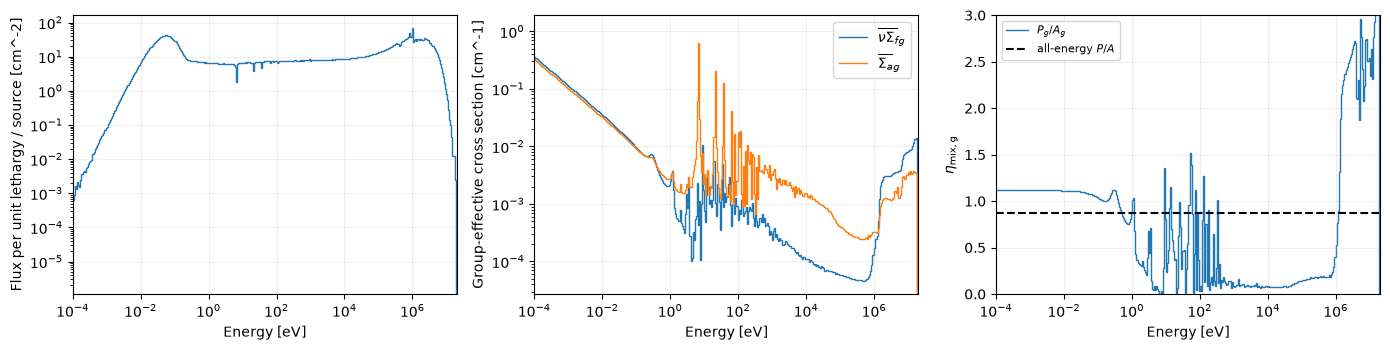

In [5]:
b = reference["bins"]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
axes[0].stairs(b["flux"] / (VOLUME * DELTA_U), ENERGY_EDGES)
axes[0].set(xscale="log", yscale="log", xlabel="Energy [eV]",
            ylabel="Flux per unit lethargy / source [cm^-2]")
axes[1].stairs(safe_ratio(b["nu-fission"], b["flux"]), ENERGY_EDGES, label=r"$\overline{\nu\Sigma_f}_g$")
axes[1].stairs(safe_ratio(b["absorption"], b["flux"]), ENERGY_EDGES, label=r"$\overline{\Sigma_a}_g$")
axes[1].set(xscale="log", yscale="log", xlabel="Energy [eV]", ylabel="Group-effective cross section [cm^-1]")
axes[1].legend()
axes[2].stairs(safe_ratio(b["nu-fission"], b["absorption"]), ENERGY_EDGES, label=r"$P_g/A_g$")
axes[2].axhline(s["eta_mix"], color="k", ls="--", label=r"all-energy $P/A$")
axes[2].set(xscale="log", xlabel="Energy [eV]", ylabel=r"$\eta_{\rm mix,g}$", ylim=(0, 3))
axes[2].legend(fontsize=8)
for ax in axes:
    ax.set_xlim(1e-4, 2e7)
fig.tight_layout()
plt.show()

**Checkpoint.** Which plotted group ratios have enough particles to be trusted?
Why is the scalar $P/A$ not the arithmetic mean of the right-hand curve?

## 5. Find the moderation optimum instead of assuming one

At low H/U, slowing down competes poorly with uranium resonance absorption.
Adding hydrogen initially helps neutrons reach energies favorable for thermal
fission. At high H/U, hydrogen absorbs an increasing fraction of the neutrons:
the mixture loses fuel utilization. The competing effects give an optimum.

The anticipated **roughly 0.85** is a scale check, not input data or an exact
benchmark. The code prints the result from the selected evaluated library,
temperature, isotope fractions, source, and fission-descendant treatment.
The maximum below is a **sampled maximum over the scanned H/U interval**, not
a proof of a global maximum for all compositions or geometries.

These demonstration histories usually take several minutes in total on a
4-thread CPU. Increase statistics for a final reference result.

In [6]:
H_TO_U_GRID = np.array([0.25, 0.5, 1, 2, 3, 4, 5, 6, 8, 12, 20, 50, 100, 300], dtype=float)
scan_rows = []
for i, ratio in enumerate(H_TO_U_GRID):
    result = fixed_case(ratio, seed=12101 + 2*i, particles=800, batches=25, label="coarse")
    scan_rows.append(result["summary"])
    pd.DataFrame(scan_rows).to_csv(RUN_ROOT / "coarse_scan.csv", index=False)
    print(f"H/U={ratio:6g}: eta_mix={result['summary']['eta_mix']:.5f}")
coarse = pd.DataFrame(scan_rows).sort_values("H_to_U").reset_index(drop=True)
display(coarse[["H_to_U", "eta_mix", "eta_fuel", "f"]].round(5))

H/U=  0.25: eta_mix=0.44725


H/U=   0.5: eta_mix=0.59079


H/U=     1: eta_mix=0.74979


H/U=     2: eta_mix=0.84857


H/U=     3: eta_mix=0.87517


...

H/U=    20: eta_mix=0.63229


H/U=    50: eta_mix=0.38713


H/U=   100: eta_mix=0.23381


H/U=   300: eta_mix=0.09111


,H_to_U,eta_mix,eta_fuel,f
0,0.25,0.44725,0.44826,0.99776
1,0.50,0.59079,0.59508,0.99280
2,1.00,0.74979,0.76553,0.97944
3,2.00,0.84857,0.89311,0.95013
4,3.00,0.87517,0.95068,0.92058
5,4.00,0.87817,0.98456,0.89194
6,5.00,0.87048,1.00694,0.86448
7,6.00,0.85656,1.02143,0.83859
8,8.00,0.82600,1.04543,0.79010
9,12.00,0.75204,1.05946,0.70983


In [7]:
coarse_best = coarse.loc[coarse.eta_mix.idxmax()]
if coarse_best.H_to_U in (H_TO_U_GRID[0], H_TO_U_GRID[-1]):
    raise RuntimeError("The sampled maximum is at a scan boundary: expand H_TO_U_GRID before refining.")
fine_grid = np.arange(max(0.25, coarse_best.H_to_U - 1.0), coarse_best.H_to_U + 1.01, 0.5)
fine_rows = []
for i, ratio in enumerate(fine_grid):
    result = fixed_case(ratio, seed=12301 + 2*i, particles=1500, batches=40, label="fine")
    fine_rows.append(result["summary"])
    pd.DataFrame(fine_rows).to_csv(RUN_ROOT / "fine_scan.csv", index=False)
    print(f"Refined H/U={ratio:g}: eta_mix={result['summary']['eta_mix']:.5f}")
fine = pd.DataFrame(fine_rows).sort_values("H_to_U").reset_index(drop=True)
best = fine.loc[fine.eta_mix.idxmax()]
BEST_H_TO_U = float(best.H_to_U)
display(fine[["H_to_U", "eta_mix", "eta_fuel", "f"]].round(5))
display(Markdown(f"**Largest refined sampled value:** η_mix = **{best.eta_mix:.4f}** at **H/U = {BEST_H_TO_U:g} atoms/atom** "
                 f"(H₂O/U = {BEST_H_TO_U/2:g}). This result was computed, not fixed to 0.85."))

Refined H/U=3: eta_mix=0.87668


Refined H/U=3.5: eta_mix=0.87874


Refined H/U=4: eta_mix=0.87841


Refined H/U=4.5: eta_mix=0.87607


Refined H/U=5: eta_mix=0.87108


,H_to_U,eta_mix,eta_fuel,f
0,3.0,0.87668,0.95243,0.92047
1,3.5,0.87874,0.96984,0.90607
2,4.0,0.87841,0.98493,0.89185
3,4.5,0.87607,0.99789,0.87792
4,5.0,0.87108,1.00780,0.86434


**Largest refined sampled value:** η_mix = **0.8787** at **H/U = 3.5 atoms/atom** (H₂O/U = 1.75). This result was computed, not fixed to 0.85.

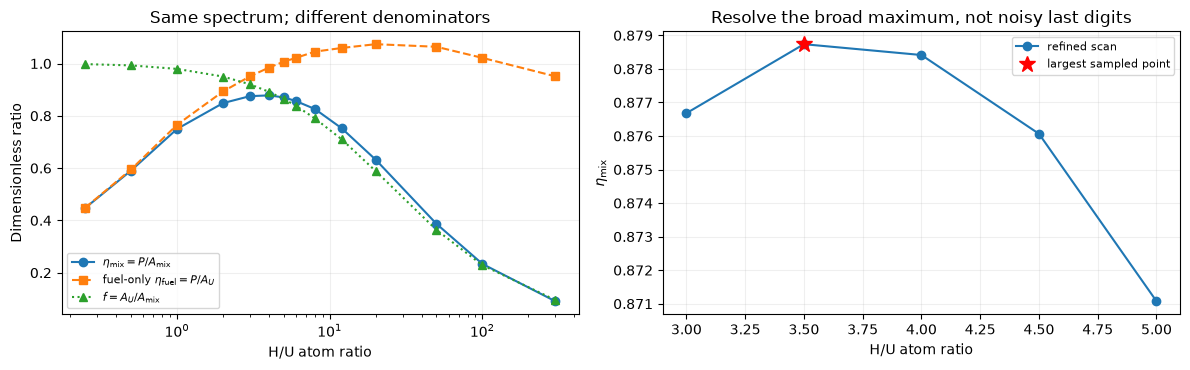

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].semilogx(coarse.H_to_U, coarse.eta_mix, "o-", label=r"$\eta_{\rm mix}=P/A_{\rm mix}$")
axes[0].semilogx(coarse.H_to_U, coarse.eta_fuel, "s--", label=r"fuel-only $\eta_{\rm fuel}=P/A_U$")
axes[0].semilogx(coarse.H_to_U, coarse.f, "^:", label=r"$f=A_U/A_{\rm mix}$")
axes[0].set(xlabel="H/U atom ratio", ylabel="Dimensionless ratio", title="Same spectrum; different denominators")
axes[0].legend(fontsize=8)
axes[1].plot(fine.H_to_U, fine.eta_mix, "o-", label="refined scan")
axes[1].plot(BEST_H_TO_U, best.eta_mix, "r*", ms=12, label="largest sampled point")
axes[1].set(xlabel="H/U atom ratio", ylabel=r"$\eta_{\rm mix}$", title="Resolve the broad maximum, not noisy last digits")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 6. Check ratio uncertainty with independent replicas

$P$ and $A$ from the same histories are correlated. Propagating their separate
standard errors as if independent can give a misleading ratio uncertainty.
Use independent-seed replicas of the selected case, each with the same history
count, and estimate the covariance of the **replica means**:

$$\operatorname{Var}(P/A)\simeq \nabla r^T\,\operatorname{Cov}(\bar P,\bar A)\,\nabla r,
\qquad \nabla r=(1/\bar A,-\bar P/\bar A^2).$$

These fresh replicas also reduce the upward selection bias of reusing the
noisiest winning scan point. Five replicas are a teaching check, not a strong
confidence statement about the exact optimal H/U. To establish its location,
repeat the neighboring points as well; report a broad optimum if they overlap.

In [9]:
replica_rows = []
for i, seed in enumerate([12501, 12511, 12521, 12531, 12541], start=1):
    replica = fixed_case(BEST_H_TO_U, seed=seed, particles=1200, batches=35, label="replica")
    replica_rows.append(replica["summary"])
    pd.DataFrame(replica_rows).to_csv(RUN_ROOT / "replicas.csv", index=False)
    print(f"Replica {i}: eta_mix={replica['summary']['eta_mix']:.5f}")
replicas = pd.DataFrame(replica_rows)
pair = replicas[["P", "A"]].to_numpy()
P_bar, A_bar = pair.mean(axis=0)
cov_of_mean = np.cov(pair, rowvar=False, ddof=1) / len(pair)
gradient = np.array([1.0 / A_bar, -P_bar / A_bar**2])
eta_confirmed = P_bar / A_bar
eta_se = np.sqrt(max(0.0, gradient @ cov_of_mean @ gradient))
display(replicas[["seed", "P", "A", "eta_mix"]].round(6))
print(f"Independent-replica estimate at H/U={BEST_H_TO_U:g}: eta_mix = {eta_confirmed:.5f} +/- {eta_se:.5f} (estimated 1 SE)")
print(f"Difference from the approximate 0.85 guide: {eta_confirmed - 0.85:+.4f}; do not tune the model to remove it.")

Replica 1: eta_mix=0.88010


Replica 2: eta_mix=0.88171


Replica 3: eta_mix=0.87916


Replica 4: eta_mix=0.87995


Replica 5: eta_mix=0.87987


,seed,P,A,eta_mix
0,12501,7.389925,8.396690,0.880100
1,12511,7.479551,8.483033,0.881707
2,12521,7.423583,8.443980,0.879157
3,12531,7.358385,8.362308,0.879947
4,12541,7.405909,8.417089,0.879866


Independent-replica estimate at H/U=3.5: eta_mix = 0.88016 +/- 0.00042 (estimated 1 SE)
Difference from the approximate 0.85 guide: +0.0302; do not tune the model to remove it.


## 7. A fixed source is not yet an eigenvalue problem

At the selected composition, suppressing fission descendants preserves the
specified 1 MeV source spectrum but removes subsequent fission generations.
Its production score still counts the **expected** fission-neutron production;
those neutrons simply are not transported. Compare its $P/A$ with the main,
multiplying fixed-source result before drawing a conclusion about $k$.

In [10]:
nonmultiplying = fixed_case(BEST_H_TO_U, seed=12701, particles=2000, batches=40,
                           multiplying=False, label="without-descendants")
display(pd.DataFrame([
    {"source treatment": "1 MeV source; no fission descendants", **nonmultiplying["summary"]},
    {"source treatment": "1 MeV external source plus fission descendants", "H_to_U": BEST_H_TO_U,
     "eta_mix": eta_confirmed, "P": P_bar, "A": A_bar},
])[["source treatment", "H_to_U", "P", "A", "eta_mix"]].round(5))

,source treatment,H_to_U,P,A,eta_mix
0,1 MeV source; no fission descendants,3.5,0.81753,1.00028,0.81730
1,1 MeV external source plus fission descendants,3.5,7.41147,8.42062,0.88016


## 8. Scaffold the $k$-eigenvalue problem

The externally driven multiplying problem has an imposed source $q$:

$$[\mathcal L-\mathcal S]\phi = q + \mathcal F\phi.$$

The eigenvalue problem instead asks for a self-consistent shape with no
continuing external source:

$$[\mathcal L-\mathcal S]\phi_k=\frac{1}{k}\mathcal F\phi_k,\qquad
\mathcal F\phi_k=\chi(E)\int\nu\Sigma_f(E')\phi_k(E')\,dE'.$$

Here $\mathcal L$ contains loss (and streaming, which has no net leakage in our
reflecting cell). The displayed factorized $\chi$ is schematic; OpenMC samples
the isotope-/incident-energy-dependent fission distributions from its data.

**Generation iteration:** guess a fission source → transport a generation →
tally/bank its fission neutrons → normalize the next source → repeat. Discard
inactive generations while the source shape settles. For this nonleaking
homogeneous model, OpenMC's reported $k_{\rm eff}$ is $k_\infty$.

Only the settings below change. The former 1 MeV source is now an **initial
source-bank guess**, not the energy of every generation. A converged answer
should not depend on that initial guess. Even a subcritical material has a
well-defined fundamental eigenvalue because the fission population is
renormalized between generations.

In [11]:
eigen_model, eigen_material, eigen_cell = make_model(
    H_to_U=BEST_H_TO_U, multiplying=True, particles=3000, batches=130, seed=12901)
eigen_model.settings.run_mode = "eigenvalue"
eigen_model.settings.inactive = 30
eigen_model.settings.generations_per_batch = 1
# Retain the initial 1 MeV source ONLY as a starting guess.
# Active generations obtain their sources from fission, not an external beam.
attach_reaction_tallies(eigen_model, eigen_material, eigen_cell)
eigen = run_and_read(eigen_model, "eigenvalue", BEST_H_TO_U)
e = eigen["summary"]
print(f"k_inf = {e['k']:.5f} +/- {e['k_sd']:.5f} (OpenMC estimated 1 SE)")
print(f"P/A in the converged eigenvalue spectrum = {e['eta_mix']:.5f}")

k_inf = 0.88954 +/- 0.00164 (OpenMC estimated 1 SE)
P/A in the converged eigenvalue spectrum = 0.88831


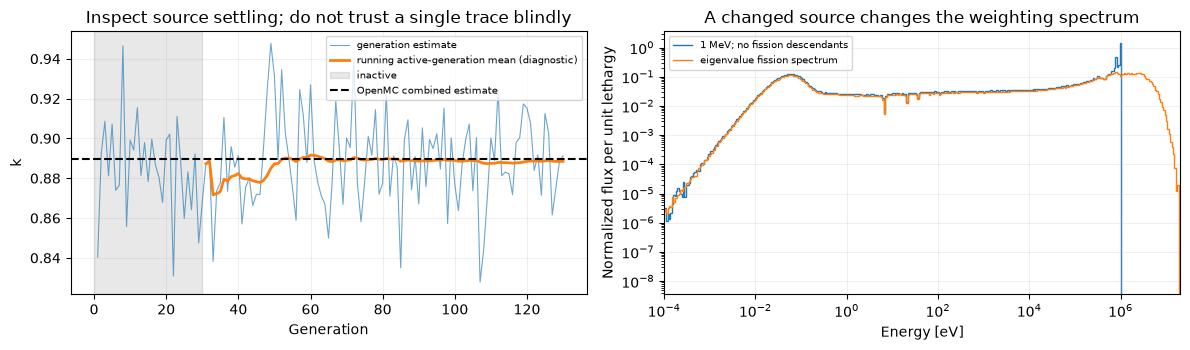

In [12]:
kgen = eigen["k_generation"]
inactive = eigen_model.settings.inactive
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(np.arange(1, len(kgen)+1), kgen, lw=0.8, alpha=0.65, label="generation estimate")
active_k = kgen[inactive:]
axes[0].plot(np.arange(inactive+1, len(kgen)+1), np.cumsum(active_k)/np.arange(1, len(active_k)+1),
             lw=2, label="running active-generation mean (diagnostic)")
axes[0].axvspan(0, inactive, color="gray", alpha=0.18, label="inactive")
axes[0].axhline(e["k"], color="k", ls="--", label="OpenMC combined estimate")
axes[0].set(xlabel="Generation", ylabel="k", title="Inspect source settling; do not trust a single trace blindly")
axes[0].legend(fontsize=7)
for label, result in [("1 MeV; no fission descendants", nonmultiplying), ("eigenvalue fission spectrum", eigen)]:
    bins = result["bins"]["flux"]
    normalized = bins / bins.sum() / DELTA_U
    axes[1].stairs(normalized, ENERGY_EDGES, label=label)
axes[1].set(xscale="log", yscale="log", xlim=(1e-4, 2e7), xlabel="Energy [eV]",
            ylabel="Normalized flux per unit lethargy", title="A changed source changes the weighting spectrum")
axes[1].legend(fontsize=7)
fig.tight_layout()
plt.show()

### Why the eigenvalue rate ratio nearly equals $k_\infty$

With zero leakage and neutron-conserving non-fission scattering, integrating
the eigenvalue equation gives $k_\infty=P/A_{\rm mix}$ **using $\phi_k$**.
It does not license inserting an arbitrary 1 MeV-source spectrum.

Evaluated data also include small non-fission multiplying reactions such as
$(n,2n)$. Let $G_s=R_{\nu s}-R_s$ be the excess scattering-neutron production,
obtained from `nu-scatter` minus `scatter`. The corresponding balance is

$$A_{\rm mix}=G_s+P/k,\qquad k=\frac{P}{A_{\rm mix}-G_s}.$$

For a multiplying fixed source normalized to one external neutron,
$A_{\rm mix}-P-G_s\simeq1$. These are statistical checks, not identities to
force by rescaling tallies. The combined OpenMC $k$ estimate and a ratio of
tally means need not be numerically identical at finite statistics.

In [13]:
comparison = pd.DataFrame([
    {"calculation": "1 MeV, descendants suppressed", "eta_mix": nonmultiplying["summary"]["eta_mix"], "k_inf": np.nan},
    {"calculation": "multiplying 1 MeV fixed source (replicas)", "eta_mix": eta_confirmed, "k_inf": np.nan},
    {"calculation": "eigenvalue spectrum", "eta_mix": e["eta_mix"], "k_inf": e["k"]},
])
display(comparison.round(6))
print(f"Fixed-source reference: A - P - G_s = {s['A'] - s['P'] - s['scatter_excess']:.5f} (expect about 1)")
print(f"Eigenvalue balance: P/(A-G_s) = {e['k_balance']:.5f}; OpenMC k = {e['k']:.5f}")
validation = {
    "openmc_version": openmc.__version__, "cross_sections": str(XS_XML),
    "temperature_K": TEMPERATURE, "density_g_cm3": 1.0,
    "coarse_H_to_U_range": [float(H_TO_U_GRID.min()), float(H_TO_U_GRID.max())],
    "best_sampled_H_to_U": BEST_H_TO_U, "confirmed_eta_mix": float(eta_confirmed),
    "eta_mix_replica_SE": float(eta_se), "nonmultiplying_eta_mix": nonmultiplying["summary"]["eta_mix"],
    "k_inf": e["k"], "k_inf_SE": e["k_sd"], "eigenvalue_eta_mix": e["eta_mix"],
    "eigenvalue_k_balance": e["k_balance"],
}
(RUN_ROOT / "validation_summary.json").write_text(json.dumps(validation, indent=2) + "\n")
display(Markdown(f"**Result for this model/data set:** the confirmed mixture ratio is **{eta_confirmed:.3f}** "
                 f"near **H/U={BEST_H_TO_U:g}**, on the expected roughly 0.85 scale but not forced to it. "
                 f"The separate eigenvalue calculation gives **k∞={e['k']:.3f}**."))

,calculation,eta_mix,k_inf
0,"1 MeV, descendants suppressed",0.817299,NaN
1,multiplying 1 MeV fixed source (replicas),0.880157,NaN
2,eigenvalue spectrum,0.888306,0.88954


Fixed-source reference: A - P - G_s = 1.00528 (expect about 1)
Eigenvalue balance: P/(A-G_s) = 0.89003; OpenMC k = 0.88954


**Result for this model/data set:** the confirmed mixture ratio is **0.880** near **H/U=3.5**, on the expected roughly 0.85 scale but not forced to it. The separate eigenvalue calculation gives **k∞=0.890**.

## 9. Student extensions / next lesson

- Repeat the neighboring H/U points with independent seeds. Is the location of
  the maximum resolved, or should it be reported as a range?
- Verify $\eta_{\rm mix}=\eta_{\rm fuel}f$ at each point. Explain why the two η
  curves need not have the same maximizing composition.
- Change the eigenvalue **initial guess** to thermal neutrons; increase inactive
  generations and compare the converged $k$ and spectrum. A transient trace
  alone is not a sufficient convergence study.
- Double the number of particles and then active batches separately. Discuss
  uncertainty, inter-generation correlation, and source convergence.
- Replace the material's natural uranium by an explicitly specified isotope
  mixture only after documenting that this is a new model. Use eigenvalue mode
  rather than assuming the multiplying fixed-source problem still converges.
- State which changes would be required for leakage, a heterogeneous lattice,
  or multigroup cross sections. Neither this moderation optimum nor its H/U
  value is a universal optimum for those different problems.